# PEMS03 邻接矩阵构建

按照 DCRNN / TrafficStream / EAC 的标准做法，基于传感器间的地理距离，使用 **Thresholded Gaussian Kernel** 构建邻接矩阵：

$$
W_{ij} = \begin{cases} \exp\!\left(-\dfrac{d(v_i,v_j)^2}{\sigma^2}\right) & \text{if } \exp\!\left(-\dfrac{d(v_i,v_j)^2}{\sigma^2}\right) \ge \epsilon \\ 0 & \text{otherwise} \end{cases}
$$

- $d(v_i, v_j)$: 传感器 $i$ 和 $j$ 之间的距离（此处用 Haversine 地理距离近似道路距离）
- $\sigma$: 距离的标准差
- $\epsilon$: 阈值，低于此值的边置零以保证稀疏性

**示例**: 构建 PEMS03 2006 年的邻接矩阵。

In [1]:
import os
import numpy as np
import pandas as pd
from math import radians, cos, sin, asin, sqrt

# ============ 配置 ============
YEAR = 2006
FLOW_CSV = f"./pems03/pems03_{YEAR}_flow.csv"
META_DIR = "../meta/d03"
EPSILON = 0.1       # Gaussian kernel 阈值 (DCRNN 默认)
OUTPUT_PATH = f"./pems03/{YEAR}_adj.npz"

## 1. 从 flow CSV 获取当年的 station ID 列表

In [2]:
# 只需要读 header，不用读全部数据
flow_header = pd.read_csv(FLOW_CSV, index_col=0, nrows=0)
station_ids = [int(c) for c in flow_header.columns]
N = len(station_ids)
print(f"{YEAR} 年 station 数量: {N}")
print(f"Station ID 范围: {min(station_ids)} ~ {max(station_ids)}")
print(f"前 10 个: {station_ids[:10]}")

2006 年 station 数量: 313
Station ID 范围: 311831 ~ 314301
前 10 个: [311831, 311832, 311844, 311845, 311847, 311864, 311903, 311930, 311972, 311973]


## 2. 从 meta 文件获取每个 station 的经纬度

策略：优先用当年最早的 meta 文件（最接近锚定日 1月1日），如有缺失再逐一回退到更早/更晚的 meta 文件。

In [3]:
def load_all_meta(meta_dir, prefix="d03_text_meta_"):
    """加载目录中所有 meta 文件，按日期排序，返回 [(date_str, DataFrame), ...]"""
    files = []
    for f in sorted(os.listdir(meta_dir)):
        if f.startswith(prefix) and f.endswith(".txt"):
            files.append(os.path.join(meta_dir, f))
    return files


def collect_station_coords(station_ids, meta_dir):
    """
    为每个 station_id 找到其经纬度。
    依次扫描所有 meta 文件（按日期排序），直到全部找齐。
    """
    needed = set(station_ids)
    coords = {}  # station_id -> (lat, lon)
    
    meta_files = load_all_meta(meta_dir)
    
    for mf in meta_files:
        if not needed:
            break
        meta = pd.read_csv(mf, sep="\t", usecols=["ID", "Latitude", "Longitude"])
        for _, row in meta.iterrows():
            sid = int(row["ID"])
            if sid in needed:
                lat, lon = row["Latitude"], row["Longitude"]
                if pd.notna(lat) and pd.notna(lon) and lat != 0 and lon != 0:
                    coords[sid] = (lat, lon)
                    needed.discard(sid)
    
    return coords, needed


coords, missing = collect_station_coords(station_ids, META_DIR)
print(f"成功获取经纬度: {len(coords)}/{N}")
if missing:
    print(f"未找到经纬度的 station: {missing}")

成功获取经纬度: 313/313


## 3. 计算两两传感器间的 Haversine 距离（km）

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    """两点间的 Haversine 距离（公里）"""
    R = 6371.0  # 地球平均半径 km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a))


# 按 station_ids 顺序构建经纬度数组
lats = np.array([coords[sid][0] for sid in station_ids])
lons = np.array([coords[sid][1] for sid in station_ids])

# 计算 N x N 距离矩阵
dist_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(i + 1, N):
        d = haversine_km(lats[i], lons[i], lats[j], lons[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d

print(f"距离矩阵 shape: {dist_matrix.shape}")
print(f"距离范围: {dist_matrix[dist_matrix > 0].min():.3f} ~ {dist_matrix.max():.3f} km")
print(f"距离均值: {dist_matrix[dist_matrix > 0].mean():.3f} km")
print(f"距离标准差: {dist_matrix[dist_matrix > 0].std():.3f} km")

距离矩阵 shape: (313, 313)
距离范围: 0.009 ~ 173.311 km
距离均值: 20.015 km
距离标准差: 24.295 km


## 4. 构建 Thresholded Gaussian Kernel 邻接矩阵

$$W_{ij} = \exp\!\left(-\frac{d_{ij}^2}{\sigma^2}\right), \quad \sigma = \text{std}(d), \quad \text{置零 if } W_{ij} < \epsilon$$

In [5]:
def build_adj_gaussian(dist_matrix, epsilon=0.1):
    """
    Thresholded Gaussian Kernel 邻接矩阵 (DCRNN 标准做法)
    
    Parameters
    ----------
    dist_matrix : np.ndarray, shape (N, N), 两两距离
    epsilon     : float, 阈值 — 低于此值的 Gaussian 权重置零
    
    Returns
    -------
    adj : np.ndarray, shape (N, N)
    sigma : float, 距离标准差
    """
    # sigma = 所有非零距离的标准差
    nonzero_dists = dist_matrix[dist_matrix > 0]
    sigma = nonzero_dists.std()
    
    # Gaussian kernel
    adj = np.exp(-dist_matrix ** 2 / sigma ** 2)
    
    # 阈值截断
    adj[adj < epsilon] = 0.0
    
    # 去掉自环 (对角线置零)
    np.fill_diagonal(adj, 0.0)
    
    return adj, sigma


adj, sigma = build_adj_gaussian(dist_matrix, epsilon=EPSILON)

print(f"sigma (距离标准差): {sigma:.3f} km")
print(f"adj shape: {adj.shape}")
print(f"非零元素: {np.count_nonzero(adj)} / {N*N} ({np.count_nonzero(adj)/(N*N)*100:.2f}%)")
print(f"对称: {np.allclose(adj, adj.T)}")
print(f"对角线全零: {np.trace(adj) == 0}")
print(f"权重范围 (非零): [{adj[adj>0].min():.6f}, {adj[adj>0].max():.6f}]")
print(f"平均度 (每节点平均邻居数): {(adj > 0).sum(axis=1).mean():.1f}")

sigma (距离标准差): 24.295 km
adj shape: (313, 313)
非零元素: 90820 / 97969 (92.70%)
对称: True
对角线全零: True
权重范围 (非零): [0.100480, 1.000000]
平均度 (每节点平均邻居数): 290.2


## 5. 可视化

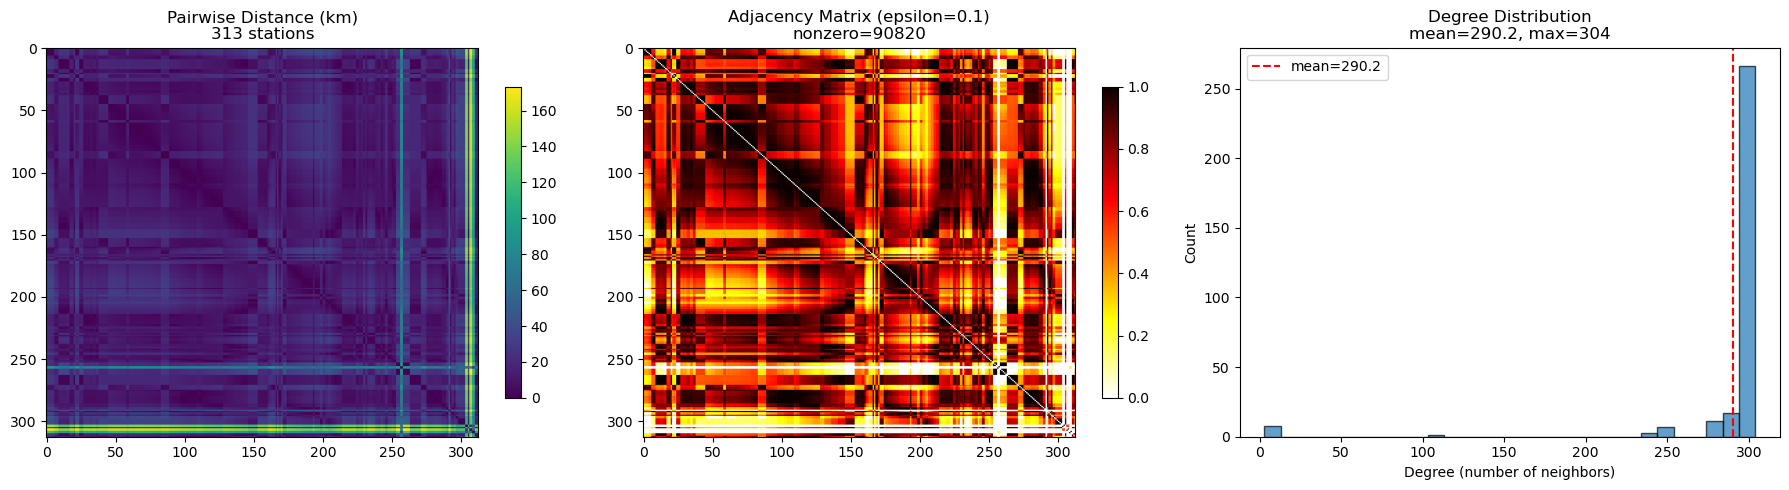

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) 距离矩阵热力图
im0 = axes[0].imshow(dist_matrix, cmap="viridis", aspect="auto")
axes[0].set_title(f"Pairwise Distance (km)\n{N} stations")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# (b) 邻接矩阵热力图
im1 = axes[1].imshow(adj, cmap="hot_r", aspect="auto", vmin=0, vmax=1)
axes[1].set_title(f"Adjacency Matrix (epsilon={EPSILON})\nnonzero={np.count_nonzero(adj)}")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# (c) 度分布直方图
degrees = (adj > 0).sum(axis=1)
axes[2].hist(degrees, bins=30, edgecolor="black", alpha=0.7)
axes[2].set_xlabel("Degree (number of neighbors)")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Degree Distribution\nmean={degrees.mean():.1f}, max={degrees.max()}")
axes[2].axvline(degrees.mean(), color="red", linestyle="--", label=f"mean={degrees.mean():.1f}")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. 与 EAC 原始 adj 对比验证（如果有的话）

In [7]:
# 与 EAC 项目中的 adj 做对比 (EAC 数据集是 PEMS district 7，非 district 3，仅做格式参考)
eac_adj_path = "../eac/data/graph/2011_adj.npz"
if os.path.exists(eac_adj_path):
    eac_adj = np.load(eac_adj_path)["x"]
    print("=== EAC 原始 adj (2011, district 7) ===")
    print(f"  shape: {eac_adj.shape}")
    print(f"  nonzero: {np.count_nonzero(eac_adj)}")
    print(f"  weight range: [{eac_adj[eac_adj>0].min():.6f}, {eac_adj[eac_adj>0].max():.6f}]")
    print(f"  avg degree: {(eac_adj > 0).sum(axis=1).mean():.1f}")
    print()
    
print("=== 本次构建的 adj (2006, district 3) ===")
print(f"  shape: {adj.shape}")
print(f"  nonzero: {np.count_nonzero(adj)}")
print(f"  weight range: [{adj[adj>0].min():.6f}, {adj[adj>0].max():.6f}]")
print(f"  avg degree: {(adj > 0).sum(axis=1).mean():.1f}")

=== EAC 原始 adj (2011, district 7) ===
  shape: (655, 655)
  nonzero: 3154
  weight range: [0.904897, 1.000000]
  avg degree: 4.8

=== 本次构建的 adj (2006, district 3) ===
  shape: (313, 313)
  nonzero: 90820
  weight range: [0.100480, 1.000000]
  avg degree: 290.2


## 7. 保存

In [8]:
# 保存格式与 EAC 一致: npz 文件, key="x"
np.savez(OUTPUT_PATH, x=adj)
print(f"已保存到 {OUTPUT_PATH}")
print(f"文件大小: {os.path.getsize(OUTPUT_PATH) / 1024:.1f} KB")

# 验证读取
adj_reload = np.load(OUTPUT_PATH)["x"]
assert np.allclose(adj, adj_reload)
print("验证通过: 读取后与原矩阵一致")

已保存到 ./pems03/2006_adj.npz
文件大小: 765.6 KB
验证通过: 读取后与原矩阵一致


## 8. (附) 行归一化预览 — 模型实际使用的形式

EAC/TrafficStream 在模型中会做行归一化: `adj = adj / row_sum`，变成随机游走矩阵。这里预览一下效果。

In [9]:
# 行归一化 (与 EAC main.py L52-54 一致)
adj_norm = adj / (np.sum(adj, axis=1, keepdims=True) + 1e-6)

print("行归一化后:")
print(f"  行和范围: [{adj_norm.sum(axis=1).min():.6f}, {adj_norm.sum(axis=1).max():.6f}]")
print(f"  (孤立节点行和为 0，其余为 1)")
isolated = (adj.sum(axis=1) == 0).sum()
print(f"  孤立节点数: {isolated}")
print(f"\n构建完成! 该 adj 可直接用于 EAC/TrafficStream 框架。")

行归一化后:
  行和范围: [0.999999, 1.000000]
  (孤立节点行和为 0，其余为 1)
  孤立节点数: 0

构建完成! 该 adj 可直接用于 EAC/TrafficStream 框架。
